# V085 — Audit and optionally re-pick the four key BCHH pressure arrivals

**Status:** validation/audit notebook; **not** part of the production paper pipeline.

The production workflow treats `PAPER_DIR/inputs/metadata/bchh_named_event_pressure_arrival_picks.csv` as the reviewed observational record. This notebook provides a reproducible way to:

1. plot those picks on the BCHH DD2/DD3 waveforms;
2. recompute same-channel differential intervals;
3. optionally make a new independent manual-picking pass;
4. compare the new pass with the authoritative picks.

**Important:** this notebook never overwrites the authoritative metadata CSV automatically. A new picking pass is written only to the validation output directory for review.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import sys
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import UTCDateTime

here = Path.cwd().resolve()
ROOT = next(
    (p for p in [here, *here.parents] if (p / "modules" / "project_config.py").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError("Run from the Falcon 9 repository or a subdirectory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from modules import project_config as config

OUT = config.notebook_output_dir(85, "audit_bchh_named_event_picks")
OUT.mkdir(parents=True, exist_ok=True)

STREAM_FILE = config.NB010_DIR / "bchh_corrected_moving_median_baseline_removed.pkl"
if not STREAM_FILE.is_file():
    raise FileNotFoundError(
        f"Missing {STREAM_FILE}. Run production Notebook 010 first."
    )

with STREAM_FILE.open("rb") as handle:
    st = pickle.load(handle)

authoritative = config.BCHH_NAMED_EVENT_ARRIVAL_PICKS.copy()
EVENT_ORDER = ["upper_stage", "lower_stage", "payload_impact", "payload_explosion"]
CHANNELS = ["DD2", "DD3"]

display(authoritative[["event", "trace_id", "channel", "pick_time_utc"]])

,event,trace_id,channel,pick_time_utc
0,upper_stage,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:15.927934Z
1,upper_stage,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:15.935523Z
2,lower_stage,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:19.427235Z
3,lower_stage,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:19.438250Z
4,payload_impact,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:28.407995Z
5,payload_impact,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:28.415926Z
6,payload_explosion,1R.BCHH.10.DD2,DD2,2016-09-01T13:07:28.987823Z
7,payload_explosion,1R.BCHH.10.DD3,DD3,2016-09-01T13:07:28.995974Z


## 1. Static audit plot of authoritative picks

This is the first check to make before any re-picking. Each waveform is centered on its own stored receiver pick. The filter is zero phase and is used only to make the onset easier to inspect.

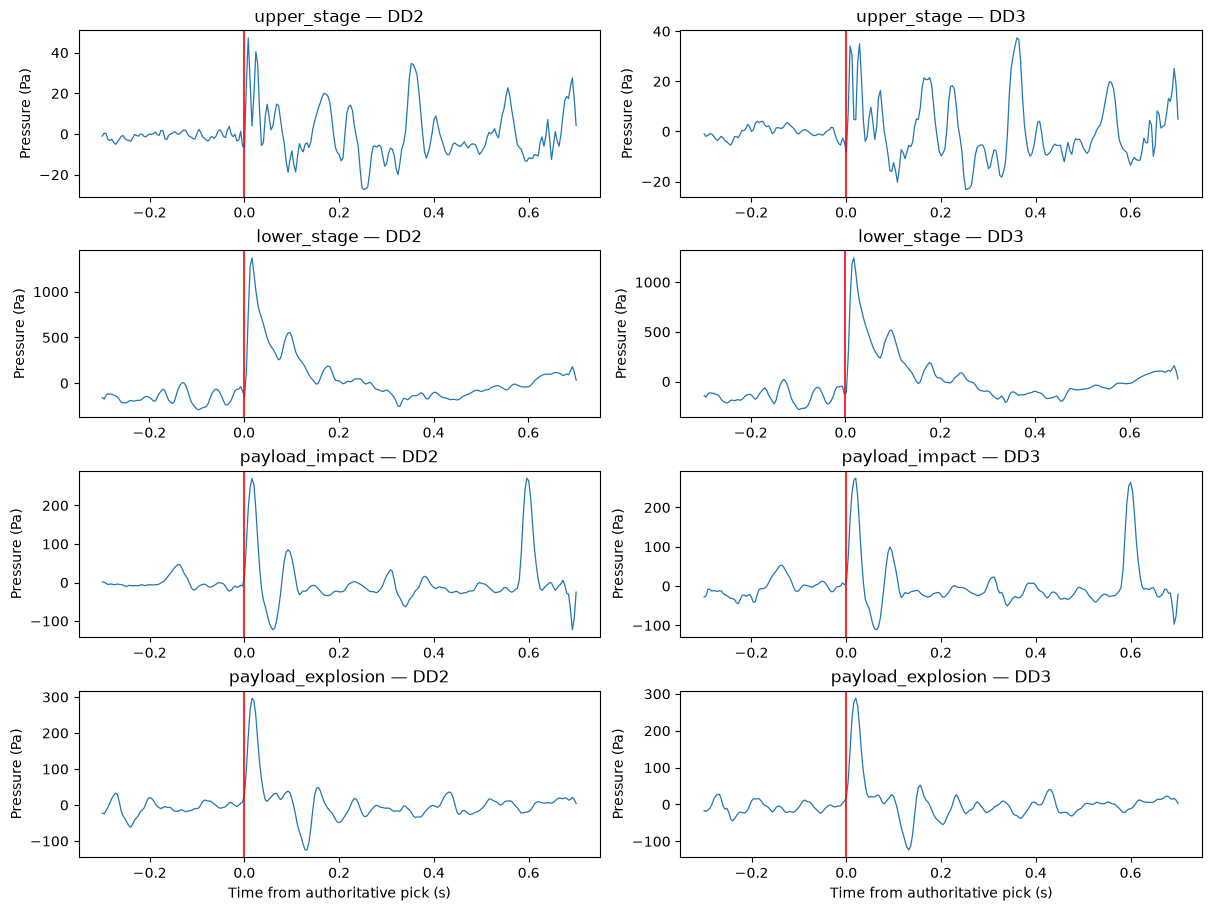

In [2]:
PRE_S = 0.30
POST_S = 0.70
FILTER_HZ = (0.5, 80.0)


def get_trace(channel):
    selected = st.select(channel=channel)
    if len(selected) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(selected)}")
    return selected[0]


def auth_pick(event, channel):
    row = authoritative.loc[
        authoritative["event"].eq(event) & authoritative["channel"].eq(channel)
    ]
    if len(row) != 1:
        raise ValueError(f"Expected one authoritative pick for {event}/{channel}")
    return row.iloc[0]["pick_time"]


fig, axes = plt.subplots(len(EVENT_ORDER), len(CHANNELS), figsize=(12, 9), constrained_layout=True)
for i, event in enumerate(EVENT_ORDER):
    for j, channel in enumerate(CHANNELS):
        ax = axes[i, j]
        t0 = auth_pick(event, channel)
        tr = get_trace(channel).copy().trim(t0 - PRE_S, t0 + POST_S)
        tr.detrend("demean")
        tr.filter(
            "bandpass",
            freqmin=FILTER_HZ[0],
            freqmax=min(FILTER_HZ[1], 0.45 * tr.stats.sampling_rate),
            corners=4,
            zerophase=True,
        )
        ax.plot(tr.times(reftime=t0), tr.data, lw=0.9)
        ax.axvline(0, color="red", lw=1.2)
        ax.set_title(f"{event} — {channel}")
        ax.set_ylabel("Pressure (Pa)")
for ax in axes[-1, :]:
    ax.set_xlabel("Time from authoritative pick (s)")
fig.savefig(OUT / "authoritative_pick_audit.pdf", bbox_inches="tight")
plt.show()

## 2. Recompute the differential intervals from the stored picks

The scientifically important quantities are same-channel intervals, because fixed channel timing offsets cancel. DD2 and DD3 are then summarized by their median.

In [3]:
def build_intervals(picks):
    tmp = picks.copy()
    tmp["pick_epoch_s"] = tmp["pick_time"].map(lambda x: float(x.timestamp))
    wide = tmp.pivot(index="channel", columns="event", values="pick_epoch_s")

    rows = []
    for event in EVENT_ORDER[1:]:
        for channel in CHANNELS:
            dt = float(wide.loc[channel, event] - wide.loc[channel, "upper_stage"])
            rows.append({
                "event": event,
                "channel": channel,
                "interval_from_upper_stage_s": dt,
            })
    per_channel = pd.DataFrame(rows)
    summary = (
        per_channel.groupby("event")["interval_from_upper_stage_s"]
        .agg(["median", "min", "max"])
        .rename(columns={"median": "median_interval_s"})
        .reset_index()
    )
    return per_channel, summary


intervals, interval_summary = build_intervals(authoritative)
display(intervals)
display(interval_summary)

# Expected values from the currently reviewed metadata are approximately:
# lower_stage        3.501014 s
# payload_impact    12.480232 s
# payload_explosion 13.060170 s

,event,channel,interval_from_upper_stage_s
0,lower_stage,DD2,3.499301
1,lower_stage,DD3,3.502727
2,payload_impact,DD2,12.480061
3,payload_impact,DD3,12.480403
4,payload_explosion,DD2,13.059889
5,payload_explosion,DD3,13.060451


,event,median_interval_s,min,max
0,lower_stage,3.501014,3.499301,3.502727
1,payload_explosion,13.060170,13.059889,13.060451
2,payload_impact,12.480232,12.480061,12.480403


## 3. Optional independent re-picking pass

For an actual independent re-pick, an interactive Matplotlib backend is required. The cell below tries `ipympl` first and Qt second. If neither is installed, it leaves the notebook in static mode and does not fail the audit sections above.

The re-picking interface records only DD2 and DD3. Click once on each subplot at the chosen impulsive onset. Re-clicking replaces that pick.

In [4]:
INTERACTIVE_AVAILABLE = False
ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
        INTERACTIVE_AVAILABLE = True
        print("Using ipympl widget backend")
    except Exception:
        try:
            ip.run_line_magic("matplotlib", "qt")
            INTERACTIVE_AVAILABLE = True
            print("Using Qt backend")
        except Exception:
            print(
                "No interactive backend found. Static audit remains available. "
                "Install ipympl or Qt to make a new picking pass."
            )

Using ipympl widget backend


In [5]:
repick_store = {}


def repick_event(event, pre_s=0.20, post_s=0.35):
    """Interactively re-pick DD2 and DD3 for one event."""
    if not INTERACTIVE_AVAILABLE:
        raise RuntimeError("No interactive Matplotlib backend is available")

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
    centres = {}

    for ax, channel in zip(axes, CHANNELS):
        centre = auth_pick(event, channel)
        centres[channel] = centre
        tr = get_trace(channel).copy().trim(centre - pre_s, centre + post_s)
        tr.detrend("demean")
        tr.filter(
            "bandpass",
            freqmin=FILTER_HZ[0],
            freqmax=min(FILTER_HZ[1], 0.45 * tr.stats.sampling_rate),
            corners=4,
            zerophase=True,
        )
        ax.plot(tr.times(reftime=centre), tr.data, lw=0.9)
        ax.axvline(0, color="0.6", ls="--", lw=0.9, label="authoritative")
        ax.set_ylabel(f"{channel} (Pa)")
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Time relative to authoritative pick (s)")
    fig.suptitle(f"Re-pick {event}: click DD2 then DD3 at the chosen onset")

    def onclick(evt):
        if evt.inaxes not in axes or evt.xdata is None:
            return
        idx = list(axes).index(evt.inaxes)
        channel = CHANNELS[idx]
        t = centres[channel] + float(evt.xdata)
        repick_store[(event, channel)] = {
            "event": event,
            "channel": channel,
            "trace_id": f"1R.BCHH.10.{channel}",
            "repick_time_utc": str(t),
            "repick_epoch_s": float(t.timestamp),
            "offset_from_authoritative_s": float(evt.xdata),
            "picked_at_utc": datetime.now(timezone.utc).isoformat(),
        }
        # Draw/replace blue pick line.
        for line in list(evt.inaxes.lines)[1:]:
            if getattr(line, "_is_repick", False):
                line.remove()
        line = evt.inaxes.axvline(float(evt.xdata), color="blue", lw=1.3)
        line._is_repick = True
        fig.canvas.draw_idle()
        print(event, channel, str(t), f"offset={evt.xdata:+.4f} s")

    fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()
    return fig


# Example usage, one event at a time:
# repick_event("upper_stage")
# repick_event("lower_stage")
# repick_event("payload_impact")
# repick_event("payload_explosion")

## 4. Save and compare a completed re-picking pass

Run this after all eight optional re-picks have been made. It writes a validation CSV and reports pass-to-pass offsets and interval changes. It does **not** alter the authoritative metadata file.

In [6]:
def repicks_to_dataframe():
    if not repick_store:
        return pd.DataFrame()
    return (
        pd.DataFrame(list(repick_store.values()))
        .sort_values(["event", "channel"])
        .reset_index(drop=True)
    )


repicks = repicks_to_dataframe()
if repicks.empty:
    print("No optional re-picks have been made.")
else:
    display(repicks)
    repick_file = OUT / "independent_repick_pass.csv"
    repicks.to_csv(repick_file, index=False)
    print("Wrote", repick_file)

    auth_compare = authoritative[["event", "channel", "pick_time"]].copy()
    auth_compare["authoritative_epoch_s"] = auth_compare["pick_time"].map(
        lambda x: float(x.timestamp)
    )
    compare = repicks.merge(
        auth_compare[["event", "channel", "authoritative_epoch_s"]],
        on=["event", "channel"],
        how="left",
    )
    compare["repick_minus_authoritative_s"] = (
        compare["repick_epoch_s"] - compare["authoritative_epoch_s"]
    )
    display(compare)
    compare.to_csv(OUT / "repick_vs_authoritative.csv", index=False)

    # Rebuild interval table using the independent picks.
    tmp = repicks.rename(columns={"repick_epoch_s": "pick_epoch_s"})
    wide = tmp.pivot(index="channel", columns="event", values="pick_epoch_s")
    interval_rows = []
    for event in EVENT_ORDER[1:]:
        for channel in CHANNELS:
            if channel in wide.index and event in wide.columns and "upper_stage" in wide.columns:
                interval_rows.append({
                    "event": event,
                    "channel": channel,
                    "repick_interval_from_upper_stage_s": float(
                        wide.loc[channel, event] - wide.loc[channel, "upper_stage"]
                    ),
                })
    repick_intervals = pd.DataFrame(interval_rows)
    display(repick_intervals)
    repick_intervals.to_csv(OUT / "repick_differential_intervals.csv", index=False)

No optional re-picks have been made.


## Audit interpretation

The authoritative DD2/DD3 picks should be retained unless an independent re-picking pass reveals a reproducible systematic problem. The pass-to-pass scatter is useful as an empirical estimate of manual onset-picking uncertainty.

For manuscript timing, use the median of the **same-channel DD2 and DD3 differential intervals**, and compare those receiver intervals only with relative event timing measured on the **same UCS-3 camera**.

In [7]:
intervals.to_csv(OUT / "authoritative_same_channel_intervals.csv", index=False)
interval_summary.to_csv(OUT / "authoritative_interval_summary.csv", index=False)
authoritative[["event", "trace_id", "channel", "pick_time_utc"]].to_csv(
    OUT / "authoritative_picks_snapshot.csv", index=False
)
print("Wrote manual-pick audit products to", OUT)

Wrote manual-pick audit products to /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/085_audit_bchh_named_event_picks
